In [167]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

### Inisialisasi Pustaka dan Definisi Algoritma Dasar
Sel ini mengimpor pustaka fundamental pengolahan data:
* `numpy`: Digunakan untuk manipulasi matriks dan array multidimensi. Citra pada dasarnya direpresentasikan sebagai matriks angka.
* `matplotlib` & `cv2`: Digunakan untuk memuat dan memvisualisasikan citra.

In [168]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:

        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    # Inisialisasi nilai jumlah awal
                    total_sum = 0
                    
                    # Looping untuk menjumlahkan piksel di dalam area filter (size x size)
                    for m in range(size):
                        for n in range(size):
                            # Mengambil nilai langsung dari matriks 'padded'
                            total_sum += padded[i + m, j + n]
                    
                    # Menghitung rata-rata (mean)
                    mean = total_sum / area
                    canvas[i, j] = mean

        case 'median':
            area = size * size
            mid_index = area // 2
            is_even = (area % 2 == 0)
            
            for i in range(height):
                for j in range(width):
                    # 1. Siapkan list kosong untuk menampung nilai piksel
                    values = []
                    
                    # 2. Ambil setiap nilai piksel di area (size x size)
                    for m in range(size):
                        for n in range(size):
                            values.append(padded[i + m, j + n])
                    
                    # 3. Urutkan list dari yang terkecil hingga terbesar
                    values.sort()
                    
                    # 4. Tentukan nilai median berdasarkan jumlah elemen (ganjil/genap)
                    if is_even:
                        # Jika total piksel genap, ambil rata-rata dua nilai di tengah
                        median = (values[mid_index - 1] + values[mid_index]) / 2.0
                    else:
                        # Jika total piksel ganjil, langsung ambil nilai yang tepat di tengah
                        median = values[mid_index]
                        
                    canvas[i, j] = median


        case 'modus':
            for i in range(height):
                for j in range(width):
                    count = {}
                    
                    # 1. Menghitung frekuensi nilai piksel 
                    for m in range(size):
                        for n in range(size):
                            val = padded[i + m, j + n]
                            
                            # Memasukkan atau menambah hitungan ke dalam dictionary
                            if val in count:
                                count[val] += 1
                            else:
                                count[val] = 1
                    
                    max_count = 0
                    mode_val = 0
                    
                    # 2. Mencari frekuensi tertinggi 
                    for val in count:
                        # Mengakses jumlah frekuensi menggunakan key (val)
                        freq = count[val] 
                        
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val

    return canvas

# cara panggil / how to call
# hasil = filter(foto_karin, 3, 'mean')

def convolution(img, kernel):
    # ukuran kernel / kernel size
    size = kernel.shape[0]
    
    # ukuran padding / padding size
    pad_size = size // 2
    
    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')
    
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)
    
    # dimensi gambar / image dimensions
    height, width = img.shape
    
    # loop baris / loop rows
    for i in range(height):
        # loop kolom / loop columns
        for j in range(width):
            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]
            
            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)
            
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = convolution(fotoMarsha, kernel)

def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    
    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)
    
    # gabung gradien absolut / combine absolute gradients
    canvas = np.abs(gx) + np.abs(gy)
    
    # normalisasi ke-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

# cara panggil / how to call
# hasil_tepi = edge(fotoTania, prewittx, prewitty)

def normalize(image):
    image = image.astype(np.float32)
    return (image * 255.0 / np.max(image)).astype(np.uint8)



def threshold_edge(img, threshold):
    canvas = np.zeros_like(img)

    canvas[img >= threshold] = 255
    canvas[img < threshold] = 0

    return canvas.astype(np.uint8)


### Penjelasan Proses Pada Sel Ini

Sel ini berisi kumpulan fungsi dasar yang dipakai untuk pengolahan citra. Fungsi-fungsi ini menjadi fondasi untuk proses smoothing, sharpening, deteksi tepi, normalisasi hasil, dan thresholding. Secara umum, alurnya adalah: citra dibaca, diproses pada tiap piksel dengan jendela tetangga, hasilnya dihitung ulang, lalu dikembalikan dalam bentuk gambar baru.

#### 1. Fungsi `filter(img, size, mode)`
Fungsi ini digunakan untuk melakukan penyaringan citra dengan tiga pilihan metode, yaitu `mean`, `median`, dan `modus`.

- `height, width = img.shape` mengambil ukuran citra grayscale karena fungsi ini diasumsikan menerima gambar satu kanal.
- `pad = size // 2` menentukan lebar padding agar piksel di tepi gambar tetap bisa diproses.
- `padded = np.pad(img, pad, mode='edge')` menambahkan padding dengan menyalin nilai piksel tepi.
- `canvas = np.zeros_like(img, dtype=np.uint8)` membuat wadah kosong untuk hasil akhir.

Pada bagian `match mode`:
- `case 'mean'` menghitung rata-rata nilai piksel pada jendela `size x size`.
  - Semua nilai piksel dalam area tetangga dijumlahkan ke `total_sum`.
  - Hasilnya dibagi dengan luas area filter (`area = size * size`).
  - Nilai rata-rata tersebut disimpan ke `canvas[i, j]`.
  - Efeknya adalah citra menjadi lebih halus karena variasi kecil antar piksel diratakan.

- `case 'median'` mengambil nilai tengah dari semua piksel dalam area tetangga.
  - Semua nilai dimasukkan ke list `values`.
  - List diurutkan dari kecil ke besar.
  - Jika jumlah elemen genap, diambil rata-rata dua nilai tengah.
  - Jika jumlah elemen ganjil, langsung diambil elemen tengah.
  - Metode ini efektif untuk mengurangi noise impulsif tanpa terlalu mengaburkan detail penting.

- `case 'modus'` mencari nilai piksel yang paling sering muncul dalam area tetangga.
  - Dictionary `count` dipakai untuk menghitung frekuensi setiap intensitas piksel.
  - Setelah semua frekuensi dihitung, nilai dengan frekuensi terbesar dipilih sebagai hasil.
  - Metode ini cenderung mempertahankan intensitas yang dominan pada area tersebut.

#### 2. Fungsi `convolution(img, kernel)`
Fungsi ini melakukan konvolusi antara citra dan kernel tertentu.

- `size = kernel.shape[0]` mengambil ukuran kernel, misalnya 3 untuk kernel 3x3.
- `pad_size = size // 2` menentukan padding yang dibutuhkan agar ukuran output tetap sama.
- `padded = np.pad(img, pad_size, mode='constant')` menambahkan padding nol di sekeliling citra.
- `canvas = np.zeros_like(img).astype(np.float32)` menyiapkan hasil dalam format float supaya perhitungan konvolusi tidak kehilangan presisi.

Di dalam loop:
- `region = padded[i:i+size, j:j+size]` mengambil potongan area citra yang sejajar dengan kernel.
- `np.sum(region * kernel)` menghitung hasil konvolusi dengan mengalikan tiap elemen region dengan kernel lalu menjumlahkannya.
- Nilai tersebut disimpan ke `canvas[i, j]`.

Konvolusi ini adalah inti dari operasi seperti smoothing, sharpening, dan pendeteksian tepi karena kernel menentukan pola perhitungan yang diterapkan pada citra.

#### 3. Fungsi `edge(img, kernelx, kernely)`
Fungsi ini dipakai untuk mendeteksi tepi dengan memanfaatkan dua kernel, satu untuk arah horizontal dan satu untuk arah vertikal.

- `gx = convolution(img, kernelx)` menghitung gradien pada sumbu X.
- `gy = convolution(img, kernely)` menghitung gradien pada sumbu Y.
- `canvas = np.abs(gx) + np.abs(gy)` menggabungkan besar gradien dari kedua arah.
- `canvas = canvas * 255.0 / np.max(canvas)` melakukan normalisasi agar hasil berada pada rentang 0–255.
- `np.clip(canvas, 0, 255).astype(np.uint8)` membatasi nilai akhir dan mengubah tipe data menjadi `uint8`.

Semakin besar perubahan intensitas antar piksel, semakin kuat nilai edge yang dihasilkan. Karena itu, area batas objek biasanya tampak lebih terang.

#### 4. Fungsi `normalize(image)`
Fungsi ini dipakai untuk menyesuaikan skala nilai citra agar kembali ke rentang 0–255.

- `image = image.astype(np.float32)` mengubah tipe data agar pembagian menghasilkan nilai desimal.
- `return (image * 255.0 / np.max(image)).astype(np.uint8)` menskalakan nilai maksimum menjadi 255.

Fungsi ini berguna ketika beberapa hasil edge dijumlahkan, karena nilai gabungannya bisa melewati batas intensitas standar gambar.

#### 5. Fungsi `threshold_edge(img, threshold)`
Fungsi ini mengubah citra edge menjadi citra biner berdasarkan nilai ambang tertentu.

- `canvas = np.zeros_like(img)` membuat citra hasil dengan nilai awal 0.
- `canvas[img >= threshold] = 255` mengubah piksel dengan intensitas di atas ambang menjadi putih.
- `canvas[img < threshold] = 0` mempertahankan piksel lain sebagai hitam.

In [169]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# The document contains the following under "Roberts Kernel" (Duplicate of Sobel):
# kernel roberts (labeled as sobel in the document)
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

### Penjelasan Proses Pada Sel Ini

Sel ini hanya mendefinisikan beberapa kernel yang akan dipakai pada tahap pengolahan citra berikutnya. Walaupun belum langsung memproses gambar, isi sel ini sangat penting karena kernel menentukan efek apa yang akan muncul saat citra dikonvolusikan.

#### 1. Kernel smoothing
- `kernelSmoothing` adalah matriks 3x3 yang elemen-elemen nilainya relatif kecil dan tersebar merata.
- Kernel ini bekerja dengan cara meratakan intensitas piksel di sekitar satu titik.
- Saat kernel digeser ke seluruh citra, nilai piksel keluaran akan dipengaruhi oleh tetangga-tetangganya.
- Dampaknya, gambar menjadi lebih halus dan noise kecil dapat berkurang.
- Kernel ini cocok dipakai sebelum proses lain yang membutuhkan citra lebih bersih.

#### 2. Kernel sharpening
- `kernelSharpening` adalah kernel 3x3 dengan nilai pusat jauh lebih besar dibanding elemen lainnya.
- Fungsi utamanya adalah mempertegas perbedaan intensitas antar piksel.
- Ketika diterapkan ke citra, detail dan tepi objek akan terlihat lebih tajam.
- Kernel ini menonjolkan area yang memiliki perubahan intensitas tinggi.
- Karena itu, sharpening sering dipakai untuk memperjelas bentuk objek setelah citra dihaluskan.

#### 3. Kernel Sobel
- `sobelX` dan `sobelY` digunakan untuk deteksi tepi berdasarkan perubahan gradien.
- `sobelX` mendeteksi perubahan intensitas pada arah horizontal, sehingga tepi vertikal lebih mudah muncul.
- `sobelY` mendeteksi perubahan intensitas pada arah vertikal, sehingga tepi horizontal lebih terlihat.
- Perbedaan bobot pada baris atas, tengah, dan bawah membuat Sobel cukup peka terhadap perubahan intensitas.
- Kernel ini biasanya menghasilkan edge yang lebih tegas dibanding filter rata-rata.

#### 4. Kernel Prewitt
- `prewittX` dan `prewittY` juga dipakai untuk deteksi tepi arah horizontal dan vertikal.
- Prinsip kerjanya mirip dengan Sobel, tetapi bobotnya lebih seragam.
- `prewittX` menyorot perubahan pada sumbu X, sedangkan `prewittY` menyorot perubahan pada sumbu Y.
- Hasil Prewitt biasanya cukup baik untuk melihat batas objek, walaupun karakternya sedikit berbeda dari Sobel.

#### 5. Kernel Roberts
- `robertsX` dan `robertsY` adalah kernel 2x2 yang lebih kecil dari Sobel dan Prewitt.
- Kernel ini mendeteksi perubahan intensitas secara diagonal.
- Karena ukurannya kecil, Roberts lebih sensitif terhadap detail lokal yang sangat tipis.
- Namun, sensitivitas tinggi ini juga membuatnya lebih mudah terpengaruh noise.
- Roberts sering dipakai untuk melihat edge sederhana dengan area pengamatan yang sempit.

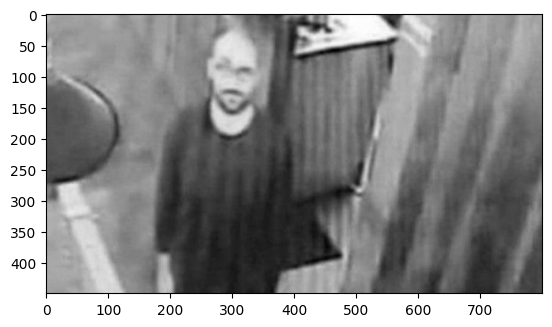

In [180]:
orangJelek = cv2.imread('Assets/backup.jpg', cv2.IMREAD_GRAYSCALE)
david = cv2.imread('Assets/david.jpg', cv2.IMREAD_GRAYSCALE)
hachimi = cv2.imread('Assets/hachimi.jpg', cv2.IMREAD_GRAYSCALE)
mambo = cv2.imread('Assets/mambo.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(orangJelek, cmap='gray')
plt.show()

### Analisis Perbedaan Hasil Smoothing, Sharpening, dan Smoothing + Sharpening
Secara teori masing-masing operator:
#### 1. Smoothing
- Smoothing adalah proses menghaluskan citra dengan cara meratakan nilai piksel di sekitar suatu titik.
- Tujuan utamanya adalah mengurangi noise, mengurangi variasi kecil, dan membuat transisi antarwarna menjadi lebih lembut.


#### 2. Sharpening
- Sharpening adalah proses mempertegas detail citra dan membuat tepi objek lebih terlihat.
- Tujuannya bukan menghilangkan noise, tetapi menonjolkan batas, tekstur, dan detail penting.
- Hasil sharpening biasanya membuat gambar tampak lebih tajam, tetapi jika citra masih ber-noise, noise itu juga bisa ikut diperkuat.


#### 3. Smoothing + Sharpening
- Tahap smoothing membantu mengurangi noise dan meratakan gangguan kecil.
- Tahap sharpening kemudian menegaskan kembali tepi dan detail penting yang masih ingin dipertahankan.
- Hasil akhirnya biasanya lebih seimbang: citra tidak terlalu berisik, tetapi detail objek tetap lebih jelas daripada hanya smoothing saja.

Berbalik dengan teori diatas dan berdasarkan output yang dihasilkan pada gambar, saya tidak melihat adanya perbedaan secara kasat mata.


#### Hubungan dengan metode mean, median, dan modus
- Smoothing pada notebook ini secara konsep paling dekat dengan filter mean, karena sama-sama meratakan nilai piksel di sekitar titik pusat.
- Median juga termasuk filter penghalus, tetapi caranya berbeda karena yang diambil adalah nilai tengah, bukan rata-rata.
- Modus memilih nilai yang paling sering muncul, sehingga cenderung mempertahankan pola intensitas yang dominan.
- Jadi, mean, median, dan modus sama-sama dipakai untuk filtering, tetapi mekanisme dan efek hasilnya berbeda.

#### Mean
- Mean menghitung rata-rata seluruh piksel dalam area kernel.
- Hasilnya paling halus karena semua nilai dalam jendela ikut memengaruhi output.
- Kekurangannya, mean mudah terpengaruh oleh nilai ekstrem, sehingga noise bisa masih tampak atau detail bisa lebih blur.
- Mean cocok untuk smoothing umum saat ingin meratakan citra secara menyeluruh.

#### Median
- Median mengambil nilai tengah setelah semua piksel diurutkan.
- Metode ini sangat baik untuk menghilangkan noise impulsif seperti bintik hitam atau putih yang menyimpang.
- Median biasanya lebih menjaga tepi objek dibanding mean, karena tidak menghitung rata-rata yang bisa menarik nilai ke arah ekstrem.
- Hasil median biasanya terlihat lebih bersih tanpa terlalu banyak blur.

#### Modus
- Modus memilih nilai piksel yang paling sering muncul dalam area kernel.
- Metode ini mempertahankan intensitas yang paling dominan di sekitar titik tersebut.
- Jika area citra memiliki pola warna yang berulang, modus akan cenderung menjaga pola dominan itu.
- Modus kurang umum dibanding mean dan median, tetapi berguna ketika ingin mempertahankan nilai yang paling sering muncul.


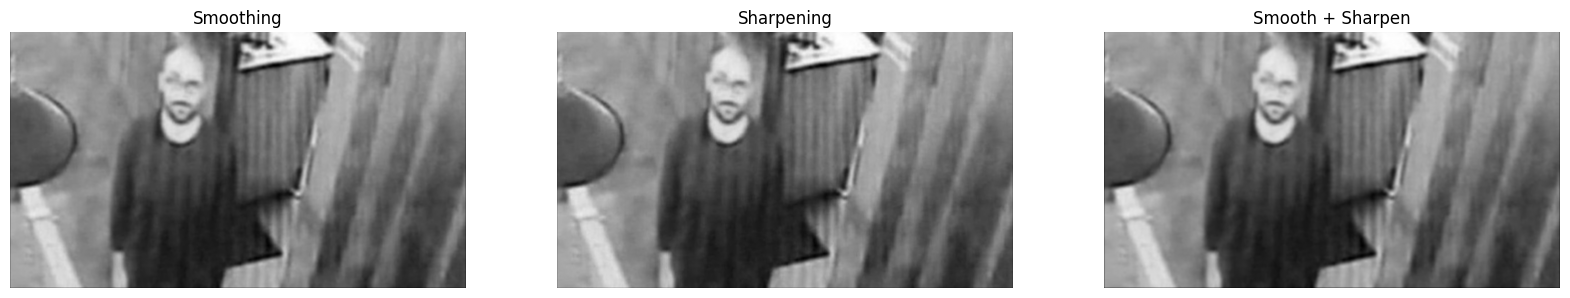

In [171]:
smoothing_backup = convolution(orangJelek, kernelSmoothing)
sharpening_backup = convolution(orangJelek, kernelSharpening)
smoothsharp_backup = convolution(smoothing_backup, kernelSharpening)

plt.figure(figsize=(20, 9))

plt.subplot(1, 3, 1)
plt.imshow(smoothing_backup, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening_backup, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothsharp_backup, cmap='gray')
plt.title('Smooth + Sharpen')
plt.axis('off')

plt.show()


### Kegunaan Operator dan Kombinasinya

Pada sel ini, beberapa operator deteksi tepi digunakan secara terpisah lalu hasilnya digabungkan kembali. Tujuannya adalah membandingkan karakter masing-masing operator, lalu melihat apakah kombinasi beberapa operator dapat memberi hasil edge yang lebih lengkap.

#### 1. Fungsi masing-masing operator

- `Prewitt` berfungsi untuk mendeteksi perubahan intensitas pada arah horizontal dan vertikal.
- `Sobel` juga mendeteksi tepi pada dua arah tersebut, tetapi bobot kernel Sobel lebih kuat di bagian tengah sehingga hasilnya biasanya lebih halus dan lebih stabil dibanding Prewitt.
- `Roberts` mendeteksi perubahan intensitas pada arah diagonal dengan kernel yang lebih kecil, sehingga sangat sensitif terhadap detail lokal dan perubahan kecil pada gambar.

#### 2. Kegunaan operator tersebut

- `Prewitt` cocok untuk melihat batas objek secara umum karena cukup sederhana dan cepat.
- `Sobel` cocok untuk deteksi edge yang lebih tegas karena lebih peka terhadap gradien dan biasanya lebih tahan terhadap noise dibanding Prewitt.
- `Roberts` cocok untuk mendeteksi perubahan intensitas yang sangat lokal, tetapi hasilnya bisa lebih berisik karena ukuran kernelnya kecil.

#### 3. Mengapa hasilnya dijumlahkan

- Hasil `prewitBackup`, `sobelBackup`, dan `robertsBackup` dijumlahkan untuk menggabungkan informasi tepi dari beberapa operator.
- Setiap operator punya kelebihan yang berbeda, jadi penggabungan ini bertujuan agar edge yang tidak tertangkap oleh satu operator bisa ditangkap oleh operator lain.
- Misalnya, jika satu operator lebih baik pada arah tertentu, operator lain bisa melengkapi bagian tepi yang masih lemah.
- Dengan begitu, hasil akhir menjadi lebih kaya informasi dan tepi objek lebih mudah terlihat.

#### 4. Fungsi `normalize()` pada hasil gabungan

- Setelah hasil beberapa operator dijumlahkan, nilai piksel bisa menjadi terlalu besar dan tidak lagi berada pada rentang 0–255.
- `normalize()` dipakai untuk mengubah skala nilai tersebut agar tetap bisa ditampilkan sebagai citra grayscale.
- Proses ini penting supaya hasil gabungan tidak tampak terlalu gelap, terlalu terang, atau overflow.

#### 5. Perbedaan hasil gabungan operator

- `Prewitt + Sobel` biasanya menghasilkan edge yang lebih lengkap karena dua operator ini sama-sama kuat pada arah horizontal dan vertikal.
- `Prewitt + Roberts` menggabungkan deteksi tepi umum dengan deteksi diagonal yang sangat sensitif.
- `Sobel + Roberts` sering memberi hasil yang tegas karena Sobel stabil, sedangkan Roberts menambah detail lokal.
- `Prewitt + Sobel + Roberts` adalah kombinasi paling lengkap karena menggabungkan tiga karakter deteksi tepi sekaligus.


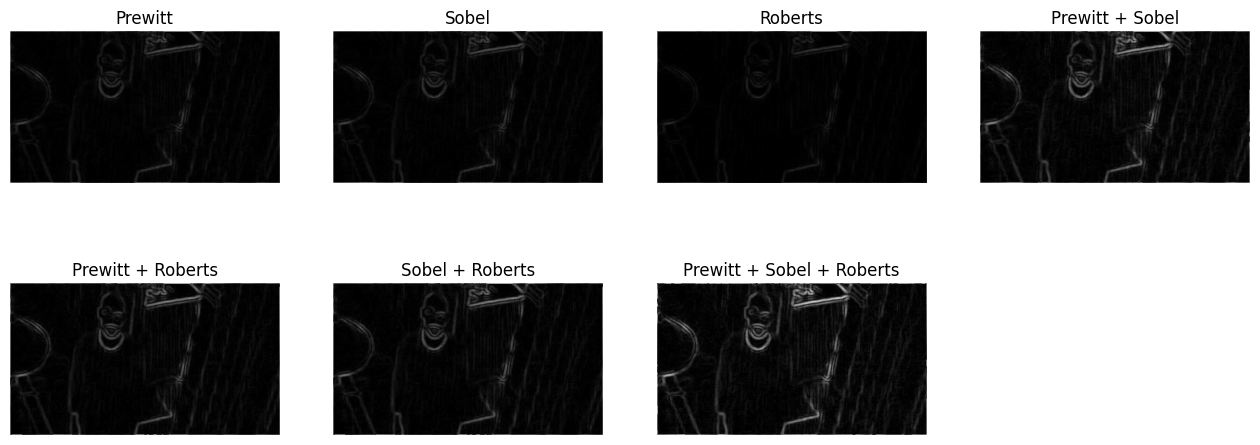

In [176]:
prewitBackup = edge(smoothsharp_backup, prewittX, prewittY)

sobelBackup = edge(smoothsharp_backup, sobelX, sobelY)

robertsBackup = edge(smoothsharp_backup, robertsX, robertsY)

prewitsobelBackup1 = normalize(prewitBackup + sobelBackup)
prewitrobertsBackup1 = normalize(prewitBackup + robertsBackup)
sobelrobertsBackup1 = normalize(sobelBackup + robertsBackup)
prewitsobelrobertsBackup1 = normalize(prewitBackup + sobelBackup + robertsBackup)


plt.figure(figsize=(16, 6))

plt.subplot(2, 4, 1)
plt.imshow(prewitBackup, cmap='gray') 
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobelBackup, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(robertsBackup, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(prewitsobelBackup1, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(prewitrobertsBackup1, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobelrobertsBackup1, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(prewitsobelrobertsBackup1, cmap='gray') 
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

plt.show()

### Pengaruh Penggunaan Threshold

Threshold digunakan untuk mengubah citra grayscale menjadi citra biner, yaitu hanya ada dua nilai utama: hitam dan putih. Pada sel ini, threshold diterapkan pada hasil edge detection dari `sobelBackup`, sehingga nilai piksel yang lebih besar dari ambang akan menjadi putih, sedangkan yang lebih kecil akan menjadi hitam.

#### Pengaruh threshold rendah
Jika threshold terlalu rendah, banyak piksel akan lolos menjadi putih. Akibatnya, garis tepi yang muncul memang lebih banyak, tetapi noise juga ikut terlihat, hasilnya biasanya tampak terlalu ramai, sehingga bentuk objek bisa menjadi kurang bersih. Threshold rendah cocok jika tujuan utamanya adalah tidak kehilangan edge kecil, tetapi risikonya citra menjadi berisik.

#### Pengaruh threshold tinggi
Jika threshold terlalu tinggi, hanya piksel dengan intensitas sangat kuat yang akan menjadi putih. Akibatnya, banyak edge lemah akan hilang, Hasilnya terlihat lebih bersih, tetapi detail penting bisa ikut terhapus. Threshold tinggi cocok jika ingin menekan noise, tetapi risikonya objek menjadi kurang lengkap karena sebagian tepi tidak terdeteksi.

#### Nilai threshold yang paling bagus untuk kasus ini
- Untuk kasus pada notebook ini, threshold yang paling seimbang umumnya berada di sekitar `30` 
- Alasannya:
 Dari beberapa hasil yang ditampilkan, `Threshold 30` sering menjadi pilihan paling aman karena edge utama masih terlihat jelas tetapi noise belum terlalu dominan.



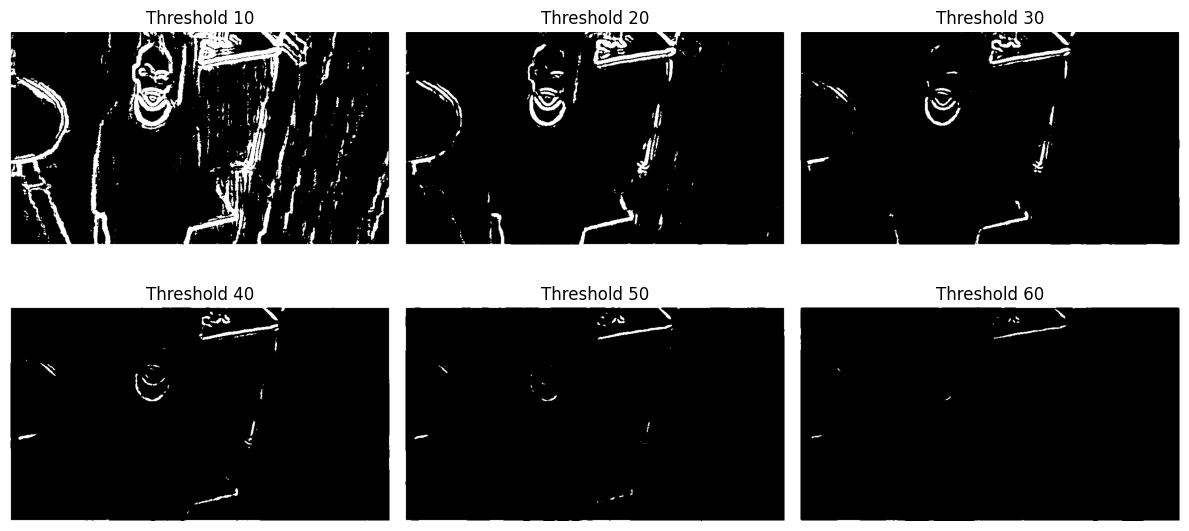

In [177]:
meansmooth = filter(smoothing_backup, 3, 'median')
sobelBackup = edge(meansmooth, sobelX, sobelY)
Threshold10 = threshold_edge(sobelBackup, 10)
Threshold20 = threshold_edge(sobelBackup, 20)
Threshold30 = threshold_edge(sobelBackup, 30)
Threshold40 = threshold_edge(sobelBackup, 40)
Threshold50 = threshold_edge(sobelBackup, 50)
Threshold60 = threshold_edge(sobelBackup, 60)


plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.title("Threshold 10")
plt.imshow(Threshold10, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Threshold 20")
plt.imshow(Threshold20, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Threshold 30")
plt.imshow(Threshold30, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Threshold 40")
plt.imshow(Threshold40, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Threshold 50")
plt.imshow(Threshold50, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Threshold 60")
plt.imshow(Threshold60, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### ANALISIS HIGHLIGHT SILUET Vsauce ###

1. Inisialisasi dan PreprocessingTahap awal melibatkan pemuatan gambar dan penyiapan ruang kerja:Konversi Warna: Gambar asli dimuat dan dikonversi ke format RGB (untuk visualisasi akhir yang akurat) dan Grayscale (untuk mempermudah proses deteksi intensitas piksel).Pendefinisian Fungsi expand_mask: Fungsi ini bekerja jika dalam sebuah jendela (window) berukuran tertentu terdapat minimal satu piksel putih (255), maka piksel pusat akan diubah menjadi putih. Ini berguna untuk menutup lubang-lubang kecil pada masker.

2. Segmentasi Berdasarkan Area dan IntensitasBagian ini adalah inti dari pembuatan masker awal. Kode melakukan iterasi pada setiap piksel di dalam bounding box tertentu:Pembatasan ROI (Region of Interest): Masker hanya dibuat di dalam koordinat x1, y1 hingga x2, y2.Thresholding Adaptif Manual: Penulis kode menggunakan ambang batas (threshold) yang berbeda untuk bagian tubuh yang berbeda karena perbedaan pencahayaan.

3. Ekspansi dan Pemangkasan MaskerUntuk memastikan seluruh tubuh tertutup dengan rapi. Fungsi expand_mask dipanggil dengan ukuran kernel 35. Ini memperbesar area masker secara signifikan agar tidak ada bagian tubuh yang "terpotong" di pinggir. Manual Trimming: Kode secara eksplisit menghapus area di luar koordinat subjek (seperti sisi kiri kepala atau area di bawah kaki) dengan memaksa nilai piksel menjadi 0. Ini memastikan masker benar-benar bersih dari gangguan latar belakang.

5. Deteksi Tepi dan Efek Visual (Highlight) memberikan output visual seperti yang terlihat pada output. 
- Edge Detection: Menggunakan fungsi edge (dengan operator Sobel) untuk mendapatkan garis luar (outline) dari masker yang sudah jadi.
- Yellow Overlay: Piksel di dalam masker (tubuh) dimanipulasi warnanya: Channel Red dan Green ditambah 80, sementara channel Blue dikurangi 60. Kombinasi ini menghasilkan filter transparan berwarna kuning.Piksel yang merupakan Outline diubah menjadi kuning terang solid ($R=255, G=255, B=80$).

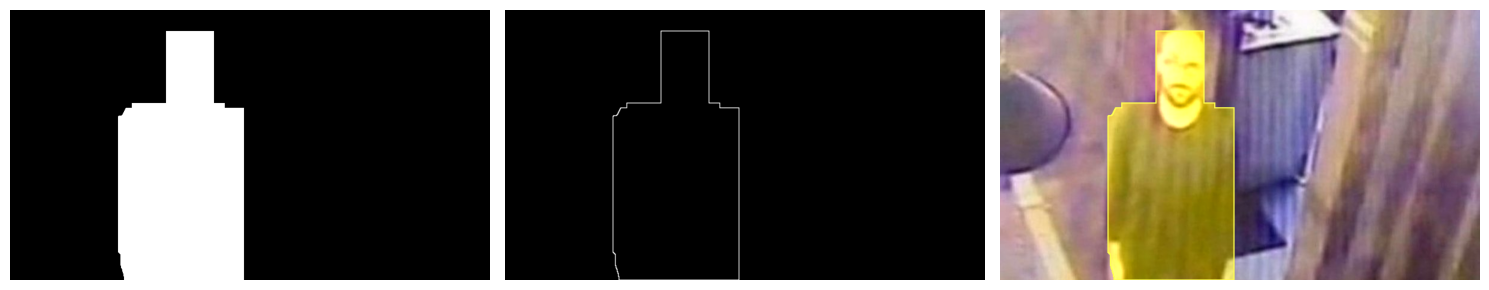

In [178]:
img = cv2.imread("Assets/backup.jpg")
backuprgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
backup = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def expand_mask(img, size):
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    h, w = img.shape
    result = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            # kalo ada minimal satu aja piksel putih, jadiin titik tengahnya putih.
            if np.any(region == 255):
                result[i, j] = 255
    return result


h, w = backup.shape
mask = np.zeros((h, w), dtype=np.uint8)

x1, y1 = 180, 35
x2, y2 = 390, 500

for i in range(h):
    for j in range(w):
        if y1 <= i <= y2 and x1 <= j <= x2:
            if i < 120:
                if 220 <= j <= 340:
                    if 170 < backup[i, j] < 245:
                        mask[i, j] = 255
            elif i < 180:  # leher
                if 220 <= j <= 340:
                    if 100 < backup[i, j] < 245:
                        mask[i, j] = 255
            else:
                if 45 < backup[i, j] < 110:
                    mask[i, j] = 255

mask_baru = np.zeros_like(mask)
for i in range(1, h-1):
    for j in range(1, w-1):
        jumlah = 0
        for a in range(-1, 2):
            for b in range(-1, 2):
                if mask[i+a, j+b] == 255:
                    jumlah += 1
        if jumlah >= 5:
            mask_baru[i, j] = 255
mask = mask_baru

mask = expand_mask(mask, 35)

for i in range(h):
    for j in range(w):
        if mask[i, j] > 127:
            mask[i, j] = 255
        else:
            mask[i, j] = 0

# dilauar vsauce
mask[:y1, :] = 0
mask[y2:, :] = 0
mask[:, :x1] = 0
mask[:, x2:] = 0
mask[y1:y1+120, 340:] = 0
mask[y1:y1+120, :260] = 0  # kiri kepala

outline = edge(mask, sobelX, sobelY)
yellowhighlight = backuprgb.copy()

for i in range(h):
    for j in range(w):
        if mask[i, j] == 255:
            yellowhighlight[i, j, 0] = min(255, int(yellowhighlight[i, j, 0]) + 80)
            yellowhighlight[i, j, 1] = min(255, int(yellowhighlight[i, j, 1]) + 80)
            yellowhighlight[i, j, 2] = max(0, int(yellowhighlight[i, j, 2]) - 60)
        if outline[i, j] > 80:
            yellowhighlight[i, j, 0] = 255
            yellowhighlight[i, j, 1] = 255
            yellowhighlight[i, j, 2] = 80

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(outline, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(yellowhighlight)
plt.axis('off')

plt.tight_layout()
plt.show()

### Penjelasan Proses Pada Sel Ini

Sel ini melakukan proses pemrosesan citra untuk memisahkan objek dari latar belakang pada gambar `david.jpg`, lalu menampilkan hasil deteksi edge, mask hasil seleksi warna, dan citra akhir yang sudah dihapus latar belakangnya.

#### 1. Membaca gambar dan menyiapkan dua versi citra
- `david = cv2.imread("Assets/david.jpg")` membaca gambar dalam format default OpenCV, yaitu BGR.
- `david_rgb = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)` mengubah citra ke RGB agar warna yang ditampilkan dengan `matplotlib` sesuai.
- `david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)` mengubah citra ke grayscale agar lebih mudah diproses pada tahap deteksi tepi.

#### 2. Mendeteksi edge pada citra grayscale
- `davidSobel = edge(david_gray, sobelX, sobelY)` menjalankan fungsi `edge()` menggunakan kernel Sobel sumbu X dan Y.
- Di dalam fungsi `edge()`, gambar dikonvolusi dua kali:
  - satu kali dengan kernel X untuk menangkap perubahan intensitas arah horizontal,
  - satu kali dengan kernel Y untuk menangkap perubahan intensitas arah vertikal.
- Hasil kedua gradien dijumlahkan secara absolut untuk mendapatkan kekuatan tepi.
- Nilai hasil kemudian dinormalisasi ke rentang 0–255 supaya mudah divisualisasikan.

#### 3. Memisahkan kanal warna RGB
- `R`, `G`, dan `B` diambil dari `david_rgb` untuk melihat komposisi warna pada setiap piksel.
- Ketiga kanal ini diubah ke `int32` agar perhitungan perbandingan warna tidak bermasalah saat dilakukan operasi penjumlahan dan pengurangan.

#### 4. Membuat mask berdasarkan dominasi warna hijau dan biru
- `mask_bg_bool = (G > R + 20) & (B > R + 20) & (G > 50)` adalah aturan untuk menandai piksel yang kemungkinan besar merupakan latar belakang.
- Logikanya:
  - jika nilai hijau lebih besar dari merah dengan selisih tertentu,
  - nilai biru juga lebih besar dari merah,
  - dan nilai hijau cukup terang,
  maka piksel dianggap bagian background.
- `mask_fg = np.where(mask_bg_bool, 0, 255).astype(np.uint8)` membalik hasil tersebut:
  - background menjadi 0,
  - foreground menjadi 255.

#### 5. Membersihkan mask dengan filter median
- `mask_fg_clean = filter(mask_fg, 3, 'median')` dipakai untuk mengurangi noise pada mask.
- Filter median bekerja dengan mengambil nilai tengah dari tetangga piksel dalam jendela 3x3.
- Efeknya, bintik-bintik kecil yang tidak konsisten bisa hilang sehingga mask menjadi lebih rapi.

#### 6. Menghapus background dari citra asli
- `david_removed = david_rgb.copy()` membuat salinan gambar agar citra asli tidak berubah.
- `david_removed[mask_fg_clean == 0] = [255, 255, 255]` mengganti area background menjadi putih.
- Artinya, hanya bagian yang dianggap foreground yang dipertahankan, sedangkan latar belakang diseragamkan menjadi putih.

#### 7. Menampilkan hasil akhir
- Plot pertama menampilkan hasil edge detection `davidSobel`.
- Plot kedua menampilkan mask yang sudah dibersihkan `mask_fg_clean`.
- Plot ketiga menampilkan hasil akhir `david_removed`, yaitu gambar yang sudah dipisahkan dari background.



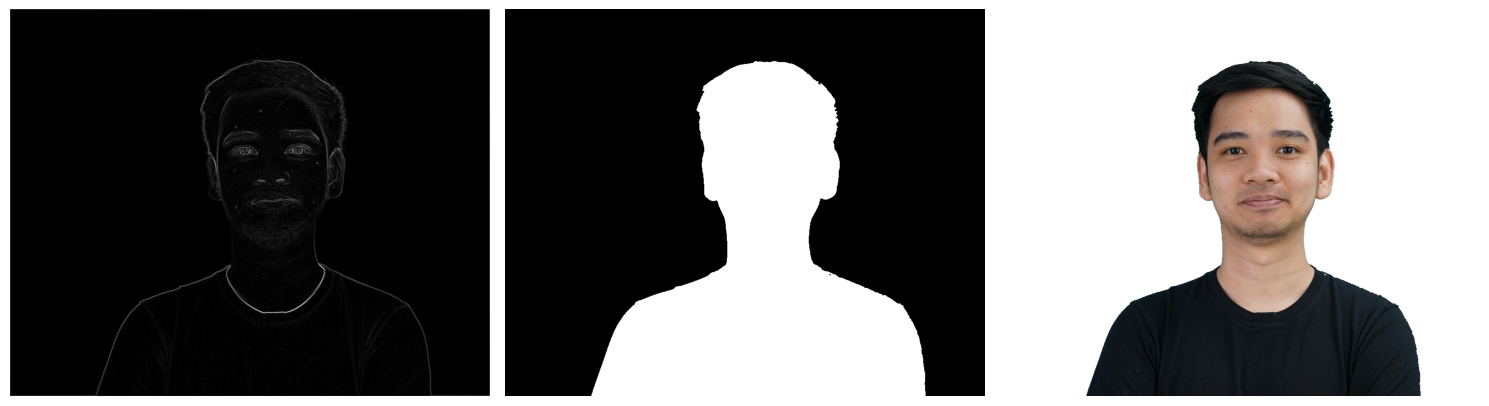

In [179]:
david = cv2.imread("Assets/david.jpg")
david_rgb = cv2.cvtColor(david, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david, cv2.COLOR_BGR2GRAY)

davidSobel = edge(david_gray, sobelX, sobelY)

R = david_rgb[:,:,0].astype(np.int32)
G = david_rgb[:,:,1].astype(np.int32)
B = david_rgb[:,:,2].astype(np.int32)

mask_bg_bool = (G > R + 20) & (B > R + 20) & (G > 50)
mask_fg = np.where(mask_bg_bool, 0, 255).astype(np.uint8)
mask_fg_clean = filter(mask_fg, 3, 'median')
david_removed = david_rgb.copy()
david_removed[mask_fg_clean == 0] = [255, 255, 255]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(davidSobel, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(mask_fg_clean, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(david_removed)
plt.axis('off')
plt.tight_layout()
